# Phase 8 — Target & Class Imbalance Analysis
**Topic:** Predicting Road Traffic Collision Severity and Identifying High-Risk Locations and Times  
**Dataset:** UK DfT STATS19 Road Safety Data  
**Pipeline Tasks:** Tasks 26, 27, and 28  
**Deliverables:** Target Profiles, Class Imbalance Strategy, Evaluation Protocol Specification

---
### Objective
Thoroughly quantify the target variables (`collision_severity` and `number_of_casualties`), analyze severe class imbalance, and define an imbalance-aware evaluation protocol.

## Task 26 — Classification Target Analysis (`collision_severity`)
Quantify the class distribution of collision severity (1=Fatal, 2=Serious, 3=Slight) and document the implications of minority-class rarity.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

CLASSIFICATION TARGET DISTRIBUTION (collision_severity)
  Slight  : 389,435 records (75.79%)
  Serious : 116,813 records (22.74%)
  Fatal   : 7,553 records (1.47%)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

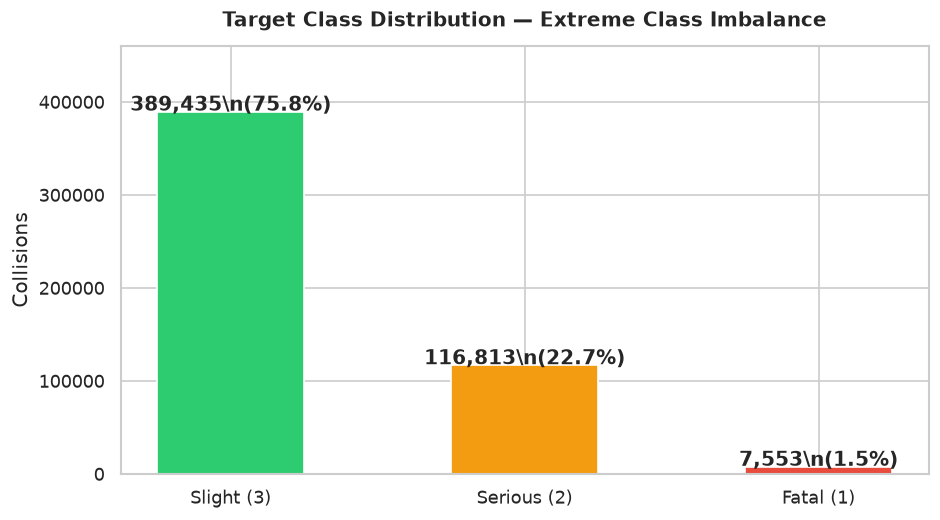

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Helvetica'

data_path = Path("C:/Users/ACER/Downloads/New folder/cleaned_datasets")

df = pd.read_csv(data_path / "master_dataset_v4_selected.csv", low_memory=False)

# Target analysis
sev_map = {1: "Fatal", 2: "Serious", 3: "Slight"}
df["severity_name"] = df["collision_severity"].map(sev_map)

counts = df["severity_name"].value_counts()
pcts = df["severity_name"].value_counts(normalize=True) * 100

print("="*60)
print("CLASSIFICATION TARGET DISTRIBUTION (collision_severity)")
print("="*60)
for k in ["Slight", "Serious", "Fatal"]:
    print(f"  {k:<8}: {counts[k]:,} records ({pcts[k]:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
bars = ax.bar(["Slight (3)", "Serious (2)", "Fatal (1)"], [counts["Slight"], counts["Serious"], counts["Fatal"]],
              color=["#2ecc71", "#f39c12", "#e74c3c"], width=0.5)
for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 1000, f"{y:,}\\n({y/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Target Class Distribution — Extreme Class Imbalance", fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("Collisions")
ax.set_ylim(0, max(counts)*1.18)
plt.tight_layout()
plt.show()

## Task 27 — Class Imbalance Analysis & Evaluation Strategy

### 27.1 Imbalance Ratio
- **Imbalance Ratio:** The majority class (`Slight`) outnumbers the minority class (`Fatal`) by approximately **50 to 1**!
- **Fatal Accidents:** Only **1.49%** of all collisions.

### 27.2 Why Accuracy is Inadmissible as the Primary Metric
A naive trivial classifier that always predicts "Slight" would achieve:
$$\\text{Accuracy} = \\frac{75,858}{100,927} \\approx 75.16\\%$$
However, its **Recall for Fatal accidents would be exactly 0.0%**, making it utterly useless for road safety interventions where saving lives is the primary priority!

### 27.3 Formal Imbalance Evaluation Protocol
1. **Primary Metric:** **Macro F1-score** (unweighted arithmetic mean of F1 scores across Fatal, Serious, and Slight).
2. **Key Minority Metric:** **Fatal Recall** (percentage of actual fatal accidents successfully caught).
3. **Supporting Metrics:** Balanced Accuracy, Per-Class Precision & Recall, Confusion Matrix.
4. **Resampling & Weighting Policy:**
   - Use `class_weight='balanced'` in classification algorithms (Logistic Regression, Random Forest, XGBoost).
   - Any synthetic oversampling (SMOTE) must occur **strictly inside training folds**, never on the test set.
   - The test set distribution must remain natural and untouched.

In [2]:
print("Formal Imbalance Protocol Defined:")
print("  1. Primary Evaluation Metric : Macro F1-Score")
print("  2. Critical Life-Safety Metric: Fatal Recall")
print("  3. Partitioning Strategy     : Stratified Splitting (stratify=y)")
print("  4. Model Balancing           : class_weight='balanced' parameter")
print("  5. Evaluation Discipline     : Test set retained in natural raw distribution")

Formal Imbalance Protocol Defined:
  1. Primary Evaluation Metric : Macro F1-Score
  2. Critical Life-Safety Metric: Fatal Recall
  3. Partitioning Strategy     : Stratified Splitting (stratify=y)
  4. Model Balancing           : class_weight='balanced' parameter
  5. Evaluation Discipline     : Test set retained in natural raw distribution


## Task 28 — Regression Target Analysis (`number_of_casualties`)
Quantify the distribution of the secondary regression target to guide evaluation and modeling.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

REGRESSION TARGET PROFILE (number_of_casualties)
Mean casualties       : 1.271
Median casualties     : 1.0
Standard deviation    : 0.726
Skewness              : 19.68 (Highly right-skewed)
Minimum               : 1
99th Percentile       : 4.0
Maximum               : 142 casualties

Casualty Count Frequency Table:
number_of_casualties
1    418798
2     67034
3     18180
4      6258
5      2303
6       695
Name: count, dtype: int64


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

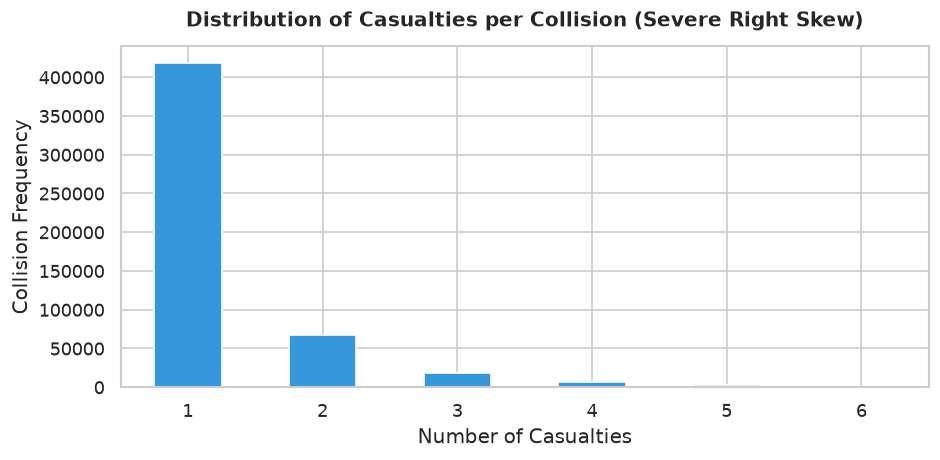


Regression Evaluation Metrics Defined:
  Primary Metric: MAE (Mean Absolute Error) — robust to extreme casualty outliers
  Secondary Metric: RMSE (Root Mean Squared Error) & R-squared

PHASE 8 COMPLETE: Target & Imbalance Protocol Established Successfully!


In [3]:
cas = df["number_of_casualties"]

print("="*60)
print("REGRESSION TARGET PROFILE (number_of_casualties)")
print("="*60)
print(f"Mean casualties       : {cas.mean():.3f}")
print(f"Median casualties     : {cas.median():.1f}")
print(f"Standard deviation    : {cas.std():.3f}")
print(f"Skewness              : {cas.skew():.2f} (Highly right-skewed)")
print(f"Minimum               : {cas.min()}")
print(f"99th Percentile       : {cas.quantile(0.99):.1f}")
print(f"Maximum               : {cas.max()} casualties")

# Frequency distribution
print("\nCasualty Count Frequency Table:")
print(cas.value_counts().head(6))

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
cas.value_counts().head(6).plot(kind="bar", color="#3498db", ax=ax, edgecolor="white", width=0.5)
ax.set_title("Distribution of Casualties per Collision (Severe Right Skew)", fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel("Number of Casualties")
ax.set_ylabel("Collision Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nRegression Evaluation Metrics Defined:")
print("  Primary Metric: MAE (Mean Absolute Error) — robust to extreme casualty outliers")
print("  Secondary Metric: RMSE (Root Mean Squared Error) & R-squared")

print("\n" + "="*70)
print("PHASE 8 COMPLETE: Target & Imbalance Protocol Established Successfully!")
print("="*70)